# Tutorial 02: Boltzmann Transport

In this tutorial you will continue the PAOFLOW post-processing workflow on bulk silicon: interpolate the PAO Hamiltonian on a dense Brillouin-zone grid, compute momentum matrix elements, evaluate Boltzmann transport tensors, and then extend the calculation with relaxation-time models.

**What you will learn**

- How interpolated velocities enter the Boltzmann transport tensors
- How the electrical conductivity, Seebeck coefficient, and electronic thermal conductivity are computed in the constant relaxation-time approximation
- How to inspect the transport tensors written by PAOFLOW
- How to replace the constant relaxation time with user-defined and built-in scattering models


::: {tip}
Try it locally: click here to download this tutorial as a notebook: [tutorial02.ipynb](tutorial02.ipynb).

The required `.save` directory assets can be obtained from: [PAOFLOW Releases](https://github.com/marcobn/PAOFLOW/releases).
:::

## Required input

This notebook uses the same bulk-silicon `.save` directory as [Tutorial 01](tutorial01.ipynb). The transport workflow starts from the same PAO Hamiltonian and then adds the quantities needed for Brillouin-zone transport integrals.

The `.save` directory must contain:

- `data-file-schema.xml` — crystal structure, k-point grid, and Kohn–Sham eigenvalues
- `atomic_proj.xml` — projection amplitudes and overlap matrices

## 1. Build the transport-ready Hamiltonian

The steps used to initialise PAOFLOW, read the atomic projections, check projectability, build the real-space PAO Hamiltonian, interpolate it on a denser Brillouin-zone grid, and compute momentum matrix elements are explained in [Tutorial 01](tutorial01.ipynb). Here they are combined into one code cell so that this notebook can focus on transport.

In [28]:
# Adjust these paths if needed
savedir = '../../examples/qe_examples/example01/silicon.save'  # Path to the QE save directory
outputdir = 'output'  # Path to the output directory for PAOFLOW results

from PAOFLOW import PAOFLOW

paoflow = PAOFLOW.PAOFLOW(
    savedir=savedir,
    outputdir=outputdir,
    smearing='gauss',
    npool=1,
    verbose=True,
)

paoflow.read_atomic_proj_QE()
paoflow.projectability()
paoflow.pao_hamiltonian()
paoflow.interpolated_hamiltonian()
paoflow.pao_eigh()
paoflow.gradient_and_momenta()
paoflow.adaptive_smearing()


────────────────────────────────────────────────────────────────────────────────────
   PPPPPP\   AA\AAAAA\   OOOOOO\  FFFFFFFF\ LLL\        OOOOOO\  WW\   WW\   WW\ 
   PP  __PP\ AA  __AA\  OO  __OO\ FF  ____/ L  |       OO  __OO\ W  |  W  |  W  |
   PP /  P  |AA /  AA | OO /  OO |FF /      L  |       OO /  OO |W  |  W  |  W  |
   PPPPPPP  |AAAAAAAA | OO |  OO |FFFFFF    L  |       OO |  OO |W  |  W  |  W  |
   PP  ____/ AA  __AA | OO |  OO |FF  _/    L  |       OO |  OO |W |  W |  W | 
   PP /      AA /  AA | OO \__OO |FF /      L  |       OO \__OO |W |  W |  W | 
   PP/       AA/   AA |  \OOOOO   |FF/       LLLLLLLL\  \OOOOO   |\WWWWWWWWWW /  
   \__|      \__|  \__|   \______/ \__|      \________|  \______/  \_________/   
────────────────────────────────────────────────────────────────────────────────────
   From DFT wavefunctions to materials properties via atomic-orbital Hamiltonians   
────────────────────────────────────────────────────────────────────────────────────

Monkho

## 2. Compute and plot transport tensors

Within the Boltzmann transport framework and the constant relaxation-time approximation, the electrical conductivity tensor is:

$$
\sigma_{\mu\nu}(E) = e^2\tau\,\frac{1}{N_k}\sum_{n,\mathbf{k}} v^\mu_{n\mathbf{k}}\,v^\nu_{n\mathbf{k}} \left(-\frac{\partial f}{\partial\varepsilon}\right)_{\varepsilon_{n\mathbf{k}}}
$$

Here $\tau$ is the (assumed constant) relaxation time and $f$ is the Fermi-Dirac distribution. PAOFLOW also computes the Seebeck coefficient and electronic thermal conductivity from energy-weighted moments of the same expression. All tensors are functions of chemical potential.

**Output:**

`kappagauss_0.dat` - contains the electronic thermal conductivity as a function of temperature.

`PFgauss_0.dat` - contains the power factor as a function of temperature.

`Seeckgauss_0.dat` - contains the Seebeck coefficient as a function of temperature.

`sigmagauss_0.dat` - contains the electrical conductivity as a function of temperature.

In [29]:
paoflow.transport(emin=-12.0, emax=2.2)

Transport in:                               5.224 sec


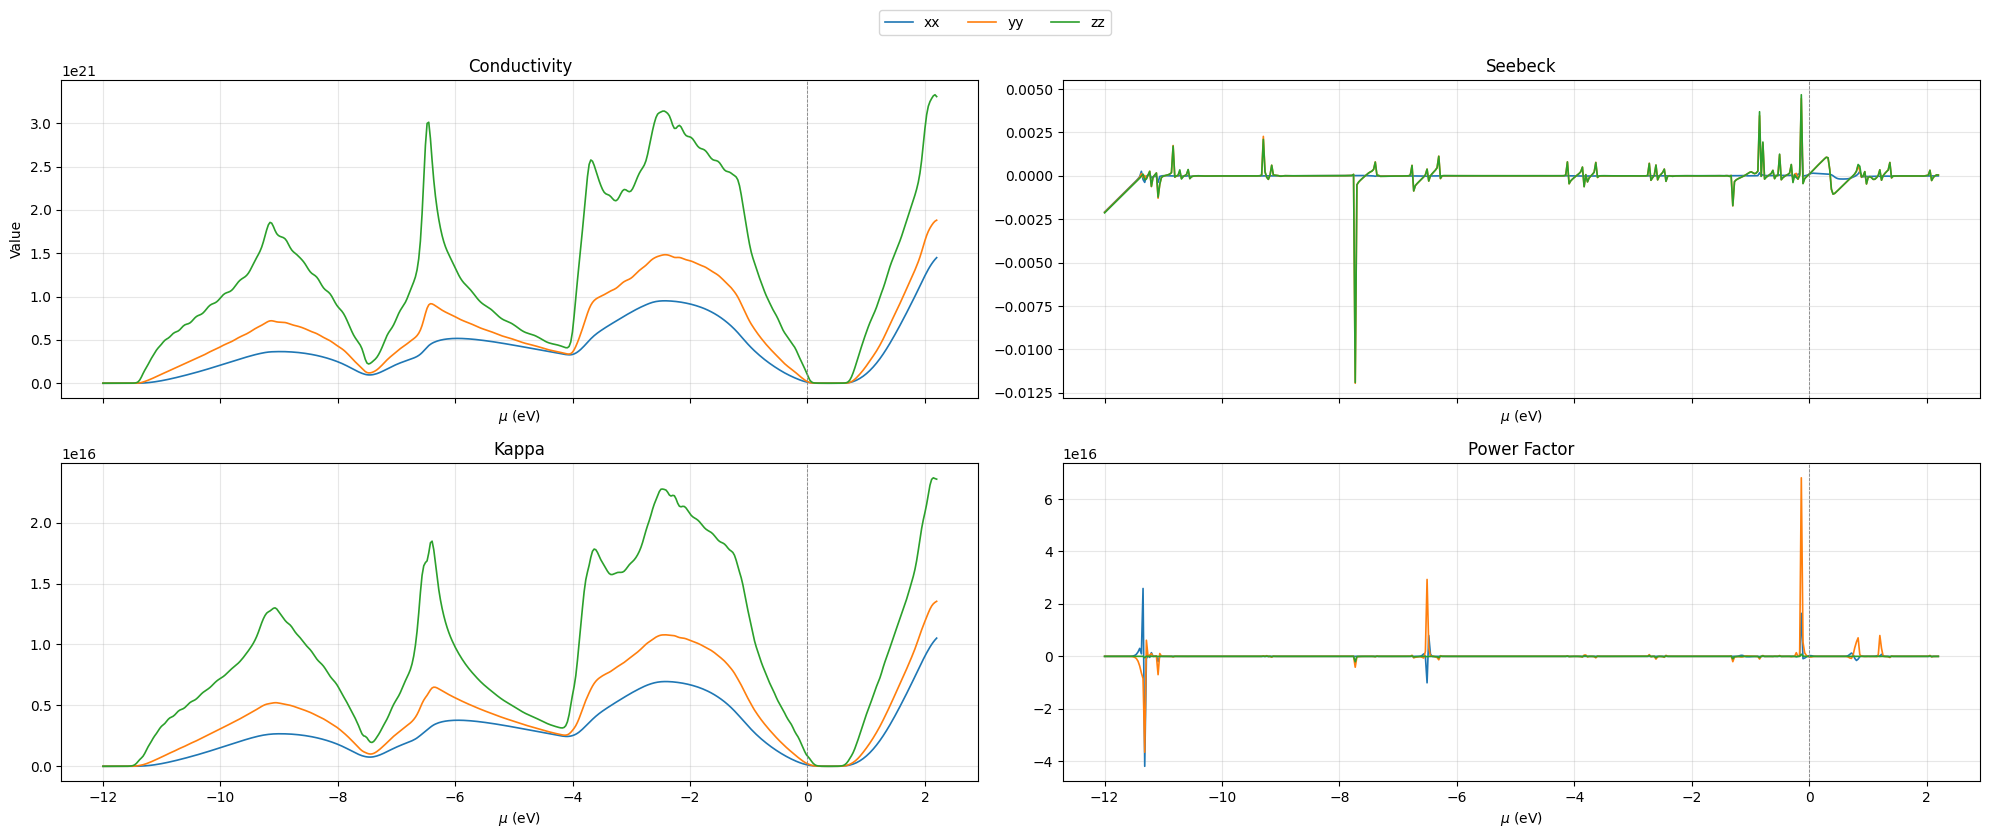

In [30]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Files
sigma_file = Path(outputdir) / 'sigmagauss_0.dat'
seebeck_file = Path(outputdir) / 'Seebeckgauss_0.dat'
kappa_file = Path(outputdir) / 'kappagauss_0.dat'
pf_file = Path(outputdir) / 'PFgauss_0.dat'

# Load data
sigma_data = np.loadtxt(sigma_file)
seebeck_data = np.loadtxt(seebeck_file)
kappa_data = np.loadtxt(kappa_file)
pf_data = np.loadtxt(pf_file)

datasets = [
    ('Conductivity', sigma_data),
    ('Seebeck', seebeck_data),
    ('Kappa', kappa_data),
    ('Power Factor', pf_data),
]

tensor_labels = ['xx', 'yy', 'zz']

fig, axes = plt.subplots(2, 2, figsize=(20, 8), sharex=True)
axes = axes.flatten()

for ax, (title, data) in zip(axes, datasets):
    if data.ndim == 1:
        data = data.reshape(1, -1)

    mu = data[:, 1]  # chemical potential

    for i, label in enumerate(tensor_labels):
        ax.plot(mu, data[:, i + 2], lw=1.2, label=label)

    ax.axvline(0.0, color='gray', ls='--', lw=0.6)
    ax.set_title(title)
    ax.set_xlabel(r'$\mu$ (eV)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Value')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()

For cubic silicon, the three diagonal tensor components should lie on top of each other within numerical accuracy. Small differences are usually a sign that the k-grid or energy resolution should be increased.


## 3. Relaxation-time models

The calculation above uses the constant relaxation-time approximation. PAOFLOW can also replace the constant $\tau$ with a list of scattering models supplied through `scattering_channels`.

Within the Boltzmann transport framework, the conductivity tensor in the constant-$\tau$ approximation is:

$$
\sigma_{\mu\nu}(E) = e^2\tau\,\frac{1}{N_k}\sum_{n,\mathbf{k}} v^\mu_{n\mathbf{k}}\,v^\nu_{n\mathbf{k}} \left(-\frac{\partial f}{\partial\varepsilon}\right)_{\varepsilon_{n\mathbf{k}}}
$$

Each channel may be either:

- the name of a built-in model such as `'acoustic'`, `'optical'`, `'impurity'`, `'polar_optical'`, or `'polar_acoustic'`
- a user-defined `TauModel` object

When several channels are included, PAOFLOW combines them using Matthiessen's rule:

$$
\frac{1}{\tau_{\mathrm{tot}}} = \sum_c \frac{w_c}{\tau_c}
$$

### 3.1 Start with built-in channels

A practical first step is to use only built-in relaxation channels. The snippet below uses acoustic and ionised-impurity scattering and defines the corresponding `tau_dict` parameters.

After validating this baseline setup, you can introduce a custom model and mix it with the built-ins. Note that all parameters used in the relaxation-time models are only for demonstration purposes and may not represent a realistic description of silicon.

In [31]:
channels = ['acoustic', 'impurity']

tau_parameters = {
    'nI': 1.0e17,
    'Zi': 1,
    'ms': 0.26,
    'eps_0': 11.7,
    'eps_inf': 11.7,
}

### 3.2 Define a custom TauModel and combine channels

The example below defines a compact acoustic-phonon `TauModel` and replaces the built-in acoustic channel while keeping ionised-impurity scattering. For polar semiconductors one may extend the same list with `'polar_optical'` and `'polar_acoustic'`.

In [32]:
from scipy.constants import hbar
from PAOFLOW.boltzmann.TauModel import TauModel

ELECTRON_MASS = 9.1093837e-31
EV_TO_J = 1.602176634e-19


def acoustic_tau(temp, eigs, params):
    temp_j = temp * EV_TO_J
    energy_j = np.clip(eigs, 0.0, None) * EV_TO_J

    sound_velocity = params['v']
    mass_density = params['rho']
    effective_mass = params['ms'] * ELECTRON_MASS
    deformation = params['D_ac'] * EV_TO_J

    tau = np.full_like(energy_j, np.inf, dtype=float)
    mask = energy_j > 0.0

    rate = (
        (2 * effective_mass) ** 1.5
        * deformation**2
        * np.sqrt(energy_j[mask])
        * temp_j
        / (2 * np.pi * mass_density * (hbar**2 * sound_velocity) ** 2)
    )
    tau[mask] = 1.0 / rate
    return tau


custom_channel = TauModel(
    function=acoustic_tau,
    params={'v': 9.0e3, 'rho': 2.33e3, 'ms': 0.26, 'D_ac': 5.0},
)

channels = [custom_channel, 'impurity']

### 3.3 Compute the chemical potential for a target doping

A temperature-dependent transport calculation usually starts from a fixed carrier density. `doping()` solves for the chemical potential $\mu(T)$ that reproduces the requested concentration.

**Output:**

`doping_*.dat` - contains the Fermi level $\mu(T)$ as a function of temperature required to keep the carrier density fixed.

In [33]:
doping_conc = -1.0e17

paoflow.doping(
    tmin=300.0,
    tmax=800.0,
    nt=11,
    emin=-2.0,
    emax=2.0,
    ne=4001,
    doping_conc=doping_conc,
)

temperature, mu = np.loadtxt(
    'output/doping_n1e+17.dat',
    usecols=(0, 1),
    unpack=True,
)

Writing Adaptive DoS Files
Doping in:                                 27.675 sec


### 3.4 Run transport one temperature at a time

The loop below evaluates `transport()` at each $(T, \mu)$ pair. `save_tensors=True` keeps the tensors in memory, which makes it straightforward to extract a scalar conductivity and convert it to a resistivity curve.

The `Ef` entry in `tau_parameters` is updated inside the loop because some built-in models use the current chemical potential as an input parameter.

In [34]:
arry, attr = paoflow.data_controller.data_dicts()
rho = []

attr['tau_dict'] = dict(tau_parameters)

for t, m in zip(temperature, mu):
    ef = abs(m)
    attr['tau_dict']['Ef'] = ef

    paoflow.transport(
        tmin=t,
        tmax=t,
        nt=1,
        emin=m,
        emax=m,
        ne=1,
        scattering_channels=channels,
        tau_dict=attr['tau_dict'],
        save_tensors=True,
        write_to_file=False,
    )

    sigma = np.trace(arry['sigma'][:, :, 0]) / 3.0
    rho.append(1e2 / sigma)

rho = np.array(rho)

Transport in:                               1.089 sec
Transport in:                               1.100 sec
Transport in:                               1.121 sec
Transport in:                               0.993 sec
Transport in:                               1.086 sec
Transport in:                               0.961 sec
Transport in:                               0.930 sec
Transport in:                               0.920 sec
Transport in:                               0.919 sec
Transport in:                               1.020 sec
Transport in:                               0.937 sec


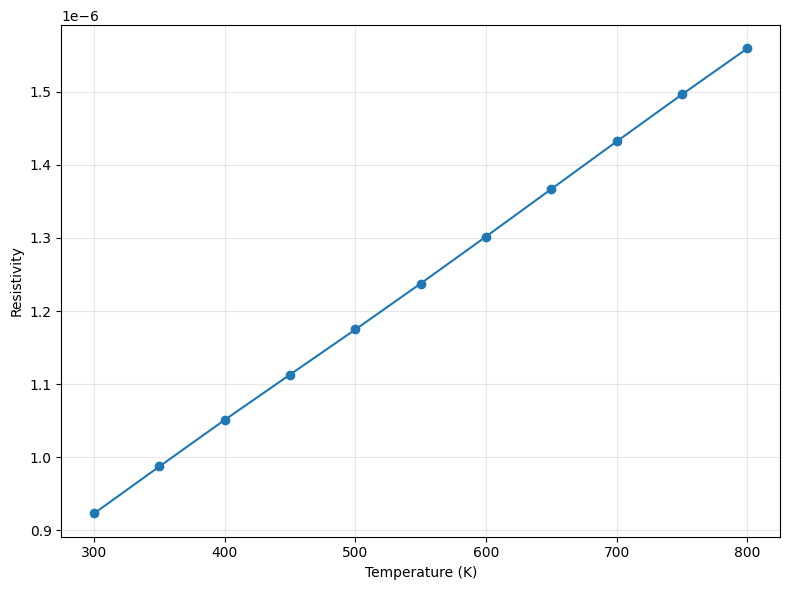

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(temperature, rho, 'o-', lw=1.5)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Resistivity')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This split example shows the pieces that matter for relaxation-time models: defining a `TauModel`, mixing it with built-in channels, solving for $\mu(T)$ at fixed doping, and then running `transport()` one temperature at a time.


In [36]:
paoflow.finish_execution()

Total CPU time =                           52.914 sec
Memory usage on rank 0:  1.6434 GB
Maximum concurrent memory usage:  1.6434 GB


## 4. Further reading
- For more details on the code framework of the relaxation-time models, refer to the [PAOFLOW documentation](https://paoflow.readthedocs.io/en/latest/transport.html#relaxation-time-models).
- For more details on the various scattering models and their application to other materials, refer to [Relaxation time approximations in PAOFLOW 2.0](https://doi.org/10.1038/s41598-022-08931-5)